# Module 2: Seasonal Crop Water Requirement (CWR), Green ETa and Blue ETa - Adapted




[![](https://raw.githubusercontent.com//wateraccounting/WaPORMOOC/main/images/colab-badge.png)](https://colab.research.google.com/github/wateraccounting/WaPORIPA/blob/main/Notebooks_v1.0/Module_2_Seasonal_CWR_GreenBlueETa.ipynb?target=\"_blank\")

### Introduction

This Notebook helps to calculate effective precipitation and
green and blue actual water consumption ( Green ETa and Season Blue ETa).

### Workflow:

We will follow these steps to complete the calculations:

0. **Import Python Libraries** import required datasets, including precipitation (PCP) (Download using the [Download_WaPORv3_Data Notebook](https://github.com/wateraccounting/WaPORMOOC/blob/main/1_WaPOR_download_colab/Download_WaPORv3_Data.ipynb) using the extend of the shapefile) , the actual evapotranspiration (AETI), and crop mask.
1. **Upload data**
2. **Resample PCP and crop mask raster layers**: align the spatial resolution and extent of PCP & Crop mask layers with Seasonal AETI.
3. **Mask the resampled raster data using the Crop mask**: Import resampled PCP and seasonal AETI datasets and apply the crop mask.
4. **Temporal Aggregation of Data**: Define functions for summing seasonal data and apply aggregation for precipitation, and actual evapotranspiration.
7. **Calculate Seasonal Effective Precipitation (Peff)**
8. **Calculate Seasonal Green ETa and Blue ETa**
9. **Zip and download the output**: ave outputs as raster files and provide a zip file for download.

### Data Used:

1. **Data Types**: PCP, AETI (outputs of Module_1a or Module_1b), kc (excel format), and crop mask layer
2. **Temporal Resolution**: Monthly (PCP) and (AETI)
3. **Season Start Date**: SOS (Start of a season)
4. **Season End Date**:  EOS (End of a season)

The function `SumSeason` used in this Notebook is adapted from the [WaPORWP repository](https://github.com/wateraccounting/WAPORWP).

© 2020 Abebe Chukalla. Licensed under **CC BY 4.0 Creative Commons**.

© 2024 IHE Delft. Licensed under **CC BY-SA Creative Commons**.


## 📋 Notebook Description

This notebook operates at the **national scale (Colombia)** and implements Module 2 of the WaPOR–ENA framework. It calculates seasonal Crop Water Requirements (CWR), Green ETa, and Blue ETa from FAO WaPOR v3 satellite products using an open-source, reproducible Python workflow.

**Study area:** All sub-basins of Colombia (national territory)  
**Period:** 2018–2024 (monthly time step)  
**Validation:** Against ENA 2022 official estimates for the year 2020  
**Outputs:** Monthly raster files of Green ETa and Blue ETa, zonal statistics per sub-basin, volumetric water consumption, agricultural water demand, and hydroclimatic anomalies.

---

## 📑 Table of Contents

| # | Section |
|---|---|
| 0 | [Import Python Libraries](#0.-Import-Python-modules/libraries) |
| 1 | [Upload Data](#1.-Upload-data) |
| 2 | [Resample PCP and Crop Mask Rasters](#2.-Resample-PCP-and-Crop-Mask-raster-layers) |
| 3 | [Mask Rasters with Crop Mask](#3.-Mask-the-resampled-raster-data-using-the-crop-mask) |
| 4 | [Import Data for Temporal Aggregation](#4.-Import-data-(masked-raster-and-crop-spesfic-data)-for-temporal-aggregation) |
| 5 | [Temporal (Seasonal) Aggregation — Define Functions & Folders](#5.-Temporal-(seasonal)-aggregation) |
| 7 | [Calculate Monthly PCP & Effective Precipitation (Peff)](#7.-Calculate-monthly-and-seasonal-precipitaiton-(PCP)-&-effective-precipitation-(Peff)) |
| 8 | [Calculate Green ETa and Blue ETa](#8.-Calculate-geen-and-blue-water-consumption-(Green-ETa-and-Blue-ETa)) |
| 9a | [Anomaly Analysis (PCP & Blue ETa)](#9.-Anomaly-Analysis) |
| 9b | [Zonal Statistics — ET per Sub-basin](#9.-ET-blue-and-green-per-basin) |
| 10 | [Volumetric Green & Blue ET per Basin](#10.-Volume-blue-and-green-per-basin) |
| 11 | [Agricultural Water Demand per Basin](#11.-Agricultural-water-demand-per-basin) |
| 12 | [Zip and Download Outputs](#12.-Zip-and-download-data) |


---

## **0. Import Python modules/libraries**

In [ ]:
!pip install rioxarray --quiet
!pip install rasterio --quiet
!pip install gdal --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.1 MB/s eta 0:00:00


In [ ]:
import os                                        # Module for interacting with the operating system (e.g., file and directory handling)
import sys                                       # Provides access to system-specific parameters and functions (e.g., command line arguments, environment)
import glob                                      # Used to retrieve files/pathnames matching a specified pattern (e.g., *.tif for all TIFF files)
import re                                        # Regular expressions module used for searching, matching, and replacing strings (e.g., re.sub() for replacing substrings)
import shutil                                    # Module for file operations such as copying and removing files/directories

import rioxarray as rio                          # An extension of xarray that supports geospatial raster data handling (e.g., reading/writing GeoTIFFs)
import rasterio                                  # Library for reading, writing, and analyzing geospatial raster data (e.g., handling .tif files)
from rasterio.warp import reproject, Resampling  # Functions for reprojection and resampling raster data to match spatial properties (e.g., CRS, resolution)

import pandas as pd                              # Data analysis and manipulation library for working with structured data (e.g., DataFrames)
import numpy as np                               # Stands for 'Numerical Python', used for scientific computing with arrays (e.g., matrix operations, statistical functions)
import calendar                                  # Module for working with calendar-related functions (e.g., generating dates, checking leap years)
import datetime                                  # Module for handling date and time operations (e.g., converting strings to dates, date arithmetic)
from osgeo import gdal                           # GDAL (Geospatial Data Abstraction Library) used for reading and writing raster and vector geospatial data formats
from scipy.interpolate import interp1d           # Function for performing 1D interpolation (e.g., linear, cubic interpolation)

import matplotlib.pyplot as plt                  # A library for creating static, animated, and interactive visualizations in Python (e.g., plotting 2D graphs, images)
import matplotlib.colors as mcolors              # Provides utilities for manipulating colors in Matplotlib (e.g., color maps, normalizing data for plots)

## **1. Upload data**

Upload/mount the data:
- The dekadal raster data (PCP) and  AETI
- The mask (crop = 1, everything else = 0)

### Upload the ZIP file containing PCP data -Copy files from Google Drive

In [ ]:
# # Upload file From google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###  Upload the crop mask files

In [ ]:
# --- Paths ---
VECTOR = '/content/drive/MyDrive/IDEAM/ET_aggregated_by_polygon_2020_ENA.gpkg'
RASTER_DRIVE = '/content/drive/MyDrive/WaPOR/Mask_crop/300m_RasterPolygons.tif'
RASTER_LOCAL = '/content/300m_RasterPolygons.tif'  # read locally (faster)

if not os.path.exists(RASTER_LOCAL):
    print('Copying raster to /content...')
    shutil.copy2(RASTER_DRIVE, RASTER_LOCAL) #shutil.copy2 for files and shutil.copytree for directory

Copying raster to /content...


📌 Crop Mask Info:
- Shape: (6539, 5455)
- Unique Values: [0. 1.]
- Pixel Size (m): (300.0, 300.0)
- CRS: ESRI:103599


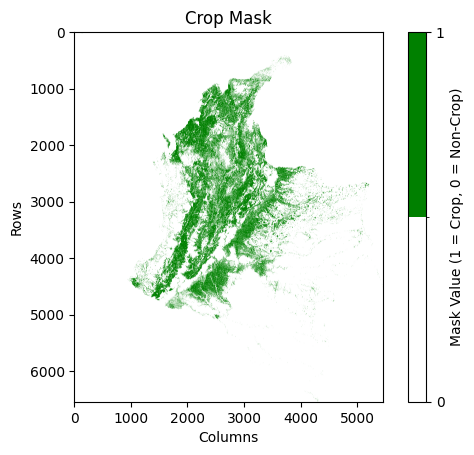

In [ ]:
# Crop mask file and its information (properties)
# Define the path to the uploaded mask file
mask_path = "/content/300m_RasterPolygons.tif"

# Read the crop mask
with rasterio.open(mask_path) as mask_src:
    crop_mask = mask_src.read(1)
    pixel_size = mask_src.res
    crs = mask_src.crs.to_string()
    pixel_size_meters = (pixel_size[0] * 111320, pixel_size[1] * 111320) if mask_src.crs.is_geographic else pixel_size

# Display mask info
print(f"📌 Crop Mask Info:\n- Shape: {crop_mask.shape}\n- Unique Values: {np.unique(crop_mask)}\n"
      f"- Pixel Size (m): {pixel_size_meters}\n- CRS: {crs}")

# Plot crop mask
plt.imshow(crop_mask, cmap=mcolors.ListedColormap(["white", "green"]), norm=mcolors.BoundaryNorm([0, 0.5, 1], 2))
plt.colorbar(label="Mask Value (1 = Crop, 0 = Non-Crop)", ticks=[0, 1])
plt.title("Crop Mask")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


In [ ]:
# Copy crop mask file to output directory
mask_path = "/content/300m_RasterPolygons.tif"   # Define the original file path
output_folder = "/content/content/output/Mask"
os.makedirs(output_folder, exist_ok=True)            # Create the folder if it doesn't exist

shutil.copy(mask_path, os.path.join(output_folder, "300m_RasterPolygons.tif"))  # Copy the file to the new file path
print(f"File copied to: {output_folder}")                                           # Confirm the copy

File copied to: /content/content/output/Mask


###  Locate the directory and data to be resampled (PCP & crop Mask) and used as a reference (AETI)

In [ ]:
# Paths to the files
dir_proj     = os.path.split(os.getcwd())[0]
dir_data     = "/content/content/output/"


input_folderPCP  = os.path.join(dir_proj, dir_data, "L1-PCP-M")
#input_folderRET  = os.path.join(dir_proj, dir_data, "L1-RET-M")
input_folderMask = os.path.join(dir_proj, dir_data, "Mask")

et_files        = os.path.join(dir_proj, dir_data, "L1-AETI-M")   # "seasonal/pywapor_AETI_S" for data from pywapor (Module_1b), "AETI_season" for data from WaPOR portal (Module_1a)
et_file         = sorted(glob.glob(et_files  + '/*.tif'))[0]


# Print paths to confirm
input_folderPCP, et_file, input_folderMask

('/content/content/output/L1-PCP-M',
 '/content/content/output/L1-AETI-M/Colombia_L1-AETI-M_NONE_month_2018-01-01.tif',
 '/content/content/output/Mask')

## **2. Resample PCP and Crop Mask raster layers**

## 0. Define function for resampling

In [ ]:
# Function for resampling

def resample_raster_files(input_folder, reference_file, output_folder):
    """
    Resamples all raster files in the input folder to match the spatial resolution and CRS
    of the reference raster file and saves the resampled files in the output folder.

    Parameters:
    input_folder (str): Path to the folder containing the raster files to be resampled.
    reference_file (str): Path to the reference raster file used for resampling.
    output_folder (str): Path to the folder where the resampled files will be saved.
    """

    # Get all raster files to be resampled
    input_files = glob.glob(os.path.join(input_folder, "*.tif"))

    # Open the reference file to get its profile
    with rasterio.open(reference_file) as ref_src:
        ref_profile = ref_src.profile

        # Loop through each raster file to be resampled
        for input_file in input_files:
            with rasterio.open(input_file) as src:
                src_data = src.read(1)

                # Create an empty array to store the resampled data
                resampled_data = np.empty((ref_profile['height'], ref_profile['width']), dtype=src_data.dtype)

                # Resample the data
                reproject(
                    source=src_data,
                    destination=resampled_data,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=ref_profile['transform'],
                    dst_crs=ref_profile['crs'],
                    resampling=Resampling.nearest
                )

                # Update profile metadata using the reference file's profile
                output_profile = src.profile.copy()
                output_profile.update(
                    transform=ref_profile['transform'],
                    height=ref_profile['height'],
                    width=ref_profile['width'],
                    crs=ref_profile['crs']
                )

                # Preserve band-specific metadata
                band1_meta = src.tags(1)

                # Save resampled file with the updated profile and original metadata
                output_file = os.path.join(output_folder, os.path.basename(input_file))
                with rasterio.open(output_file, 'w', **output_profile) as dst:
                    dst.write(resampled_data, 1)
                    dst.update_tags(1, **band1_meta)  # Preserve band metadata

    print("Resampling completed.")

## i. Resample PCP data

In [ ]:
# Paths to the files
dir_proj     = os.path.split(os.getcwd())[0]
dir_data     = "/content/content/output/"

# Resample pricipitation
input_folder   = input_folderPCP
reference_file = et_file
output_folder  = os.path.join(dir_proj, dir_data, "PCP_resampled")  #  the directory of the output folder

# Make one if the folder does not exit
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Resample using the reference raster
resample_raster_files (input_folder, reference_file, output_folder)

## ii. Resample Crop Mask layer

In [ ]:
# Paths to the files
dir_proj = os.path.split(os.getcwd())[0]
dir_data = "/content/content/output/"

# Resample Mask Data
input_folder = input_folderMask
reference_file = et_file
output_folder = os.path.join(dir_proj, dir_data, "Mask_resampled")  # Output folder for resampled mask

# Make the output folder if it does not exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Resample the mask using the reference raster
resample_raster_files(input_folder, reference_file, output_folder)


Resampling completed.


### 2.iii Reproject mask to align with PCP raster

After resampling both PCP and the crop mask to the AETI resolution, an additional reprojection step ensures the crop mask is perfectly co-registered with the PCP rasters (matching transform, CRS, and grid). This avoids pixel-alignment mismatches when multiplying raster layers later. The result is saved as `mask_match_to_pcp.tif`.


In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling

pcp_ref = "/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-01-01.tif"
mask_in = "/content/content/output/Mask_resampled/300m_RasterPolygons.tif"
mask_match = "/content/mask_match_to_pcp.tif"

with rasterio.open(pcp_ref) as ref, rasterio.open(mask_in) as src:
    profile = ref.profile.copy()
    profile.update(dtype="uint8", nodata=0, count=1, compress="lzw", tiled=True, blockxsize=512, blockysize=512)
    with rasterio.open(mask_match, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src,1),
            destination=rasterio.band(dst,1),
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=ref.transform, dst_crs=ref.crs,
            src_nodata=src.nodata, dst_nodata=0,
            resampling=Resampling.nearest  # mantiene 0/1
        )
print("Reproyected mask:", mask_match)

Reproyected mask: /content/mask_match_to_pcp.tif


## **3. Mask the resampled raster data using the crop mask**

In this section you will be importing the WaPOR data.

Import resampled PCP  and  AETI
## Step I. Import resampled raster data (WaPOR and crop mask)

In [ ]:
# Define directories
dir_proj = os.path.split(os.getcwd())[0]
dir_data = "/content/content/output/"

# Define input folders, sort files
input_folderPCP = os.path.join(dir_proj, dir_data, "PCP_resampled")
input_fhsPCP    = sorted(glob.glob(input_folderPCP + '/*.tif'))

#input_folderRET = os.path.join(dir_proj, dir_data, "RET_resampled")
#input_fhsRET    = sorted(glob.glob(input_folderRET + '/*.tif'))

input_folderETas = os.path.join(dir_proj, dir_data, "L1-AETI-M")   # Define the input folder path for seasonal AETI data:  "seasonal/pywapor_AETI_S" for data from pywapor (Module_1b), "AETI_season" for data from WaPOR portal (Module_1a)
input_fhsETas    = sorted(glob.glob(input_folderETas+ '/*.tif'))                 # Use glob to find all .tif files in the specified folder

input_folderMask = os.path.join(dir_proj, dir_data, "Mask_resampled")
input_fhsMask = sorted(glob.glob(input_folderMask + '/*.tif'))

# Output folders
output_folders = {
    "PCP": os.path.join(dir_proj, dir_data, "PCP_masked"),
    #"RET": os.path.join(dir_proj, dir_data, "RET_masked"),
    "AETIs": os.path.join(dir_proj, dir_data, "AETIs_masked")
}

# Ensure output directories exist
for folder in output_folders.values():
    os.makedirs(folder, exist_ok=True)

# Load Mask (Ensuring shape & CRS match)
mask_file = input_fhsMask[0]  # Assuming only one mask file
with rasterio.open(mask_file) as mask_raster:
    mask = mask_raster.read(1)
    mask = mask == 1  # Convert to boolean (True where mask == 1)
    mask_transform = mask_raster.transform
    mask_crs = mask_raster.crs
    mask_shape = mask_raster.shape
#input_fhsRET,
input_fhsPCP ,input_fhsETas, input_fhsMask

(['/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-01-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-02-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-03-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-04-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-05-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-06-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-07-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-08-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-09-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-10-01.tif',
  '/content/content/output/PCP_resampled/Colombia_L1-PCP-M_NONE_month_2018-11-01.tif',
  '/content/content/output/PCP_resampled/Co

## Step II. Mask the resampled raster (WaPOR) data

Crop-Specific Masking – Applying a binary masking to retain information based on the presence of a specific crop  (1 for crop presence, 0 for everything else).

In [ ]:
import os, numpy as np, rasterio
from rasterio.warp import reproject, Resampling

# Límite superior de plausibilidad (ajusta si hace falta: dekadal~1000, mensual~3000)
PLAUS_MAX = 3000.0
SENTINELS = (-9999, -32768, 32767, 65535, 3.4028235e38, -3.4028235e38)

def apply_mask_and_save(input_files, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for input_file in input_files:
        with rasterio.open(input_file) as src:
            # ¿La máscara está alineada al ráster?
            aligned = (src.crs == mask_crs) and (src.transform == mask_transform) and (src.shape == mask_shape)

            # Si no, reprojectar máscara al grid del ráster (nearest para no romper clases 0/1)
            if not aligned:
                mask_aligned = np.zeros(src.shape, dtype="uint8")
                reproject(
                    source=mask.astype("float32"),
                    destination=mask_aligned,
                    src_transform=mask_transform, src_crs=mask_crs,
                    dst_transform=src.transform, dst_crs=src.crs,
                    src_nodata=0, dst_nodata=0,
                    resampling=Resampling.nearest
                )
                mask_aligned = mask_aligned > 0
            else:
                mask_aligned = mask  # ya es booleana

            # Perfil de salida: float32 + nodata=-9999 para poder escribir NaN como nodata
            profile = src.profile.copy()
            profile.update(
                driver="GTiff", dtype="float32", count=1,
                nodata=-9999.0, compress="lzw",
                tiled=True, blockxsize=512, blockysize=512,
                BIGTIFF="IF_SAFER",
            )

            out_path = os.path.join(output_folder, os.path.basename(input_file))
            with rasterio.open(out_path, "w", **profile) as dst:
                ndv = src.nodata
                for _, win in src.block_windows(1):
                    a = src.read(1, window=win, masked=False).astype("float32")
                    m = mask_aligned[win.row_off:win.row_off+win.height,
                                     win.col_off:win.col_off+win.width]

                    # 1) limpiar: nodata/sentinelas -> NaN
                    if ndv is not None:
                        a = np.where(a == ndv, np.nan, a)
                    for v in SENTINELS:
                        a = np.where(np.isclose(a, v, rtol=0, atol=1e-3), np.nan, a)

                    # 2) precip no puede ser negativa (0 es válido); cortar extremos absurdos
                    a = np.where(a < 0, np.nan, a)
                    a = np.where(a <= PLAUS_MAX, a, np.nan)

                    # 3) aplicar máscara: dentro->valor, fuera->NaN
                    a = np.where(m > 0, a, np.nan)

                    # 4) escribir (NaN -> nodata=-9999)
                    a_out = np.where(np.isfinite(a), a, -9999.0).astype("float32")
                    dst.write(a_out, 1, window=win)

            print(f"OK → {out_path}")


#### Apply masking function to PCP and AETI

The `apply_mask_and_save` function defined above is now called on both the resampled PCP and AETI rasters. Pixels outside agricultural areas (crop mask = 0) are set to NoData, restricting all subsequent calculations to cropland only.


In [ ]:
apply_mask_and_save(input_fhsPCP, output_folders["PCP"])
apply_mask_and_save(input_fhsETas, output_folders["AETIs"])
print("Masked raster files saved successfully.")


## **4. Import data (masked raster and crop spesfic data) for temporal aggregation**


## Step I. Import masked raster (WaPOR) data

In [ ]:
# import masked PCP and RET, Seasonal AETI
dir_proj     = os.path.split(os.getcwd())[0]                                     # Specify the data directory
dir_data     = "/content/content/output/"

input_folderPCP = os.path.join(dir_proj, dir_data, "PCP_masked")
input_fhsPCP    = sorted(glob.glob(input_folderPCP + '/*.tif'))

#input_folderRET = os.path.join(dir_proj, dir_data, "RET_masked")
#input_fhsRET    = sorted(glob.glob(input_folderRET + '/*.tif'))

input_folderETas = os.path.join(dir_proj, dir_data, "AETIs_masked")
input_fhsETas    = sorted(glob.glob(input_folderETas+ '/*.tif'))

input_folderMask = os.path.join(dir_proj, dir_data, "Mask_resampled")
input_fhsMask = sorted(glob.glob(input_folderMask + '/*.tif'))

#input_fhsRET

# Print paths to confirm
input_fhsPCP, input_fhsETas, input_fhsMask

## Step II. Import crop-specific information, define the season

## A) Define seasons

Here the start (SOS) and end (EOS) dates for each season are defined.

In [ ]:
season_periods = {
    'January':   {'SOS': '2018-01-01', 'EOS': '2018-01-31'},
    'February':  {'SOS': '2018-02-01', 'EOS': '2018-02-28'},
    'March':     {'SOS': '2018-03-01', 'EOS': '2018-03-31'},
    'April':     {'SOS': '2018-04-01', 'EOS': '2018-04-30'},
    'May':       {'SOS': '2018-05-01', 'EOS': '2018-05-31'},
    'June':      {'SOS': '2018-06-01', 'EOS': '2018-06-30'},
    'July':      {'SOS': '2018-07-01', 'EOS': '2018-07-31'},
    'August':    {'SOS': '2018-08-01', 'EOS': '2018-08-31'},
    'September': {'SOS': '2018-09-01', 'EOS': '2018-09-30'},
    'October':   {'SOS': '2018-10-01', 'EOS': '2018-10-31'},
    'November':  {'SOS': '2018-11-01', 'EOS': '2018-11-30'},
    'December':  {'SOS': '2018-12-01', 'EOS': '2018-12-31'}
}

### **5.1. Define function for temporal aggregation**

This script defines the SumSeason function, which will be used in the following sections to aggregate seasonal data.

© 2020 Abebe Chukalla. Licensed under CC BY 4.0 Creative Commons.

In [ ]:
# Function to sum raster values between two specified dates (sowing and harvesting)

# Set verbose to True to print messages, False to suppress them
verbose = False  # Toggle message printing

def log_message(msg, level="INFO"):
    """Prints messages if verbose is enabled."""
    if verbose:
        print(f"{level}: {msg}")

def extract_date_from_filename(filename):
    """Extracts date (YYYY-MM-DD) from filename, returns None if missing."""
    match = re.search(r'(\d{4}-\d{2}-\d{2})', filename)
    return datetime.datetime.strptime(match.group(1), '%Y-%m-%d').date() if match else log_message(f"Date missing in {filename}", "WARNING")

def determine_raster_period(start_date, file_timedelta="dekadal"):
    """Returns raster end date based on user-defined time step (daily, dekadal, or monthly)."""
    days = {"daily": 1, "dekadal": 10, "monthly": 30}.get(file_timedelta.lower(), 10)
    return start_date + datetime.timedelta(days=days)


def SumSeason(input_fhs, sowing_date, harvesting_date, file_timedelta="dekadal"):
    """
    This function sums the raster data that fall within the provided sowing and harvesting dates.

    Parameters:
    - input_fhs: List of file paths to the input raster files.
    - sowing_date: The starting date of the season (as a datetime.date object).
    - harvesting_date: The ending date of the season (as a datetime.date object).
    - file_timedelta: The user-defined time interval for raster data ("dekadal" or "monthly"). Defaults to "dekadal".

    Returns:
    - Sums: Aggregated raster data for the specified period.
    """

    Sums = None  # Initialize sum variable

    for i, in_fh in enumerate(input_fhs):
        log_message(f"\nProcessing raster file {i+1}: {in_fh}")

        try:
            # Ensure the file exists before proceeding
            if not os.path.exists(in_fh):
                log_message(f"File not found: {in_fh}. Skipping...", "ERROR")
                continue

            # Attempt to open the raster file
            try:
                ds = rio.open_rasterio(in_fh)
            except Exception as e:
                log_message(f"Failed to open raster file {in_fh}: {e}", "ERROR")
                continue  # Skip this file

            log_message(f"Attributes found in raster: {ds.attrs}", "DEBUG")

            # Handle missing fill values
            if '_FillValue' in ds.attrs:
                ds = ds.where(ds != ds.attrs['_FillValue'])  # Mask invalid values

            # Extract start and end dates
            try:
                if 'start_date' in ds.attrs and 'end_date' in ds.attrs:
                    raster_startdate = datetime.datetime.strptime(ds.attrs['start_date'], '%Y-%m-%d').date()
                    raster_enddate = datetime.datetime.strptime(ds.attrs['end_date'], '%Y-%m-%d').date()
                else:
                    log_message(f"Missing 'start_date' or 'end_date' in attributes for {in_fh}. Extracting from filename.", "WARNING")
                    raster_startdate = extract_date_from_filename(os.path.basename(in_fh))
                    if raster_startdate:
                        raster_enddate = determine_raster_period(raster_startdate, file_timedelta)
                    else:
                        log_message(f"Could not determine start date for {in_fh}. Skipping file.", "ERROR")
                        continue
            except Exception as e:
                log_message(f"Error parsing date attributes in {in_fh}: {e}", "ERROR")
                continue

            log_message(f"Raster period: {raster_startdate} to {raster_enddate}")

            # Determine the portion of raster data to sum
            try:
                if (raster_startdate >= sowing_date) and (raster_enddate <= harvesting_date):
                    Sum = ds
                elif (raster_startdate < sowing_date) and (raster_enddate > sowing_date) and (raster_enddate < harvesting_date):
                    Sum = ds * ((raster_enddate - sowing_date).days / (raster_enddate - raster_startdate).days)
                elif (raster_startdate > sowing_date) and (raster_startdate < harvesting_date) and (raster_enddate > harvesting_date):
                    Sum = ds * ((harvesting_date - raster_startdate).days / (raster_enddate - raster_startdate).days)
                elif (sowing_date >= raster_startdate) and (harvesting_date <= raster_enddate):
                    Sum = ds * ((harvesting_date - sowing_date).days / (raster_enddate - raster_startdate).days)
                else:
                    log_message(f"Skipping {in_fh}: Does not overlap with the season.", "INFO")
                    continue  # Skip rasters outside the season
            except Exception as e:
                log_message(f"Error calculating raster fraction for {in_fh}: {e}", "ERROR")
                continue

            # Sum raster data
            if Sums is None:
                Sums = Sum
            else:
                Sums += Sum

        except Exception as e:
            log_message(f"Unexpected error processing file {in_fh}: {e}", "ERROR")

    if Sums is None:
        log_message("No valid raster files found within the season.", "ERROR")
        return None

    return Sums


#### Alternative SumSeason function (commented out)

This cell contains an earlier, simplified version of `SumSeason`. It is kept for reference but is not used in the current workflow — the active version above includes additional error handling and verbose logging. Uncomment only if you need to revert to the simpler approach.


In [ ]:
# # Function to sum raster values between two specified dates (sowing and harvesting)
# def SumSeason(input_fhs, sowing_date, harvesting_date):
#     """
#     This function sums the raster data that fall within the provided sowing and harvesting dates.

#     Parameters:
#     - input_fhs: List of file paths to the input raster files
#     - sowing_date: The starting date of the season (as a datetime.date object)
#     - harvesting_date: The ending date of the season (as a datetime.date object)

#     Returns:
#     - Sums: Aggregated raster data for the specified period
#     """

#     # Initialize the cumulative sum variable for raster data
#     Sums = 0

#     # Loop through each raster file
#     for i, in_fh in enumerate(input_fhs):
#         # Open the raster file and mask out invalid data using the fill value from the attributes
#         ds = rio.open_rasterio(in_fh)
#         print ("1", ds)
#         ds = ds.where(ds != ds.attrs['_FillValue'])  # Ignore fill values in the raster data

#         # Save the attributes of the first raster for later use (metadata such as start/end dates)
#         if i == 0:
#             attrs = ds.attrs
#             print ("2",attrs)

#         # Extract the start and end dates of the raster from its attributes
#         raster_startdate = datetime.datetime.strptime(ds.attrs['start_date'], '%Y-%m-%d').date()
#         print ("3",raster_startdate)
#         raster_enddate = datetime.datetime.strptime(ds.attrs['end_date'], '%Y-%m-%d').date()
#         print ("4",raster_enddate)

#         # Case 1: The entire raster period is within the sowing and harvesting dates
#         if (raster_startdate >= sowing_date) and (raster_enddate <= harvesting_date):
#             Sum = ds  # Use the full raster data
#             Sums += Sum  # Accumulate it into the total sum

#         # Case 2: Raster starts before sowing but ends within the growing season
#         elif (raster_startdate < sowing_date) and (raster_enddate > sowing_date) and (raster_enddate < harvesting_date):
#             # Add the fraction of the raster data that overlaps with the sowing date
#             Sum = ds * ((raster_enddate - sowing_date) / (raster_enddate - raster_startdate))
#             Sums += Sum  # Accumulate the fractional sum

#         # Case 3: Raster starts within the growing season but ends after the harvesting date
#         elif (raster_startdate > sowing_date) and (raster_startdate < harvesting_date) and (raster_enddate > harvesting_date):
#             # Add the fraction of the raster data that overlaps with the harvesting date
#             Sum = ds * ((harvesting_date - raster_startdate) / (raster_enddate - raster_startdate))
#             Sums += Sum  # Accumulate the fractional sum

#         # Case 4: Sowing and harvesting dates are both within the raster period
#         elif (sowing_date >= raster_startdate) and (harvesting_date <= raster_enddate):
#             # Add the fraction of the raster data that overlaps with both the sowing and harvesting dates
#             Sum = ds * ((harvesting_date - sowing_date) / (raster_enddate - raster_startdate))
#             Sums += Sum  # Accumulate the fractional sum

#     # Update the raster attributes with new seasonal start and end dates
#     attrs.update({
#         'start_date': datetime.datetime.strftime(SOS, '%Y-%m-%d'),  # Seasonal start date
#         'end_date': datetime.datetime.strftime(EOS, '%Y-%m-%d'),    # Seasonal end date
#         'units': 'mm/season'  # Update units to reflect seasonal aggregation
#     })

#     # Remove unnecessary attributes to clean up the metadata
#     del attrs['number_of_days']
#     del attrs['temporal_resolution']
#     del attrs['units_conversion_factor']

#     # Assign the updated attributes to the summed raster
#     Sums.attrs = attrs

#     # Return the final aggregated raster data
#     return Sums


### **5.2. Defines (and create) the output folder for the results**

In [ ]:
# Define the result directory and output folder path
dir_proj = os.path.split(os.getcwd())[0]  # Get the parent directory of the current working directory
dir_data = r"/content/output/"            # Specify the directory where the output will be stored

output_folderPCP         = os.path.join(dir_proj, dir_data, "PCP_season")
output_folderPCPmon      = os.path.join(dir_proj, dir_data, "PCP_month")
output_folderPCPeff      = os.path.join(dir_proj, dir_data,    "PCPeff_season")
output_folderPCPeffmon   = os.path.join(dir_proj, dir_data, "PCPeff_month")
output_folderGreenBlueET = os.path.join(dir_proj, dir_data,    "GreenBlueET_season")

# Make one if the folder does not exit
# List of output folders
output_folders = [
    output_folderPCP, output_folderPCPeff, output_folderGreenBlueET, output_folderPCPmon, output_folderPCPeffmon
]

# Create folders if they don't exist
for folder in output_folders:
    os.makedirs(folder, exist_ok=True)


#### Copy crop mask to the output results folder

The crop mask raster is copied into the main output directory so it is co-located with the seasonal ETa results. This makes it easier to load in later steps without needing to reference the original path.


In [ ]:
# Copy crop mask file to result directory
dir_proj = os.path.split(os.getcwd())[0]  # Get the parent directory of the current working directory
dir_data = r"/content/output/"            # Specify the directory where the output will be stored

mask_path = "/content/content/output/Mask_resampled/mask_match_to_pcp.tif"   # Define the resampled crop mask file path

# Create the folder if it doesn't exist
output_folder = os.path.join(dir_proj, dir_data,    "CropMask")
os.makedirs(output_folder, exist_ok=True)

shutil.copy(mask_path, os.path.join(output_folder, "mask_match_to_pcp.tif"))  # Copy the file to the new file path
print(f"File copied to: {output_folder}")                                                    # Confirm the copy

File copied to: /content/output/CropMask


#### Load national boundary for visualization

The Colombia national boundary (`Colombia.geojson`) is loaded as a GeoDataFrame and re-projected to match the CRS of the raster outputs. It is used as an overlay in maps to provide geographic context when visualizing results at the national scale.


In [ ]:
import geopandas as gpd

col_path = "/content/Colombia.geojson"   #
col_gdf = gpd.read_file(col_path)       # read GeoJSON file
col_gdf = col_gdf.to_crs(crs)           # crs = CRS del raster que ya obtienes con ds.rio.crs


#### Free up Colab disk space

The raw WaPOR input files (AETI and PCP) are large and are no longer needed once the masked and resampled outputs have been saved. These cells delete the original input folders from the Colab environment to free up disk space before running subsequent processing steps.


In [ ]:
# # if you want to delete a folder use the code below.
!rm -rf /content/content/output/L1-AETI-M
# !rm -rf /content/tifs
# !rm -rf /content/data.zip

In [ ]:
# # if you want to delete a folder use the code below.
!rm -rf /content/content/output/L1-PCP-M
# !rm -rf /content/tifs
# !rm -rf /content/data.zip

## **7. Calculate monthly and seasonal precipitaiton (PCP) & effective precipitation (Peff)**


This script processes the monthly masked PCP rasters and applies the **USDA Soil Conservation Service (SCS) method** to calculate effective precipitation (Peff) for each month and each year in the study period (2018–2024). The Peff formula accounts for rainfall that is not lost to runoff and remains available in the crop root zone:

> *Peff = P × (125 − 0.2×P) / 125* for P ≤ 250 mm  
> *Peff = 125 + 0.1×P* for P > 250 mm

Monthly rasters for both PCP and Peff are saved in `output/PCPeff_month/`.

In [ ]:
import os, re, datetime
import numpy as np
import rioxarray as rio
import matplotlib.pyplot as plt
import gc

"""
This script processes precipitation data (PCP) and calculates effective precipitation (Peff) for each season.
It extracts geospatial info from the first PCP raster, computes monthly and seasonal PCP/Peff values, and
outputs them as raster files, along with Peff visualizations.
"""

# ---------- GeoInfo (identical to reference block, with squeeze for 2D) ----------
in_fh = input_fhsPCP[0]                         # First precipitation file
ds    = rio.open_rasterio(in_fh).squeeze()       # Open the raster file
crs   = ds.rio.crs                               # Get CRS (Coordinate Reference System) of raster
NDV   = ds.attrs.get('_FillValue', np.nan)       # Get NoData value from raster metadata
if (NDV is None) or (isinstance(NDV, float) and np.isnan(NDV)):
    NDV = ds.rio.nodata                          # Fallback if _FillValue is not set
# ----------------------------------------------------------------------------------

# Safe kwargs for to_raster (avoid passing np.nan as nodata)
def _to_raster_kwargs(crs, NDV):
    kw = {"crs": crs}
    if NDV is not None and not (isinstance(NDV, float) and np.isnan(NDV)):
        kw["nodata"] = NDV
    return kw
_rio_kw = _to_raster_kwargs(crs, NDV)

# Peff formula (USDA Soil Conservation Service method)
def peff_from_pcp(p):
    return np.where(p <= 250.0, p * (125.0 - 0.2 * p) / 125.0, 125.0 + 0.1 * p)

# Robust month parser: supports YYYY-MM, YYYY-MM-DD, YYYYMM, YYYY_MM, YYYY.MM, MM-YYYY, MM_YYYY
def month_tag(fname):
    """
    Returns (tag 'YYYY-MM', date(YYYY, MM, 1)) if parsing succeeds;
    otherwise returns (clean_filename, date.max).
    """
    base = os.path.basename(fname)

    # a) YYYY-MM(-DD)? / YYYY_MM / YYYY.MM / YYYYMM
    m = re.search(r'(?P<y>\d{4})[-_.]?(?P<m>0[1-9]|1[0-2])(?:[-_.]?\d{2})?', base)
    if m:
        y = int(m.group('y')); mm = int(m.group('m'))
        try:
            d = datetime.date(y, mm, 1)
            return f"{y:04d}-{mm:02d}", d
        except ValueError:
            pass

    # b) MM-YYYY / MM_YYYY
    m = re.search(r'(?P<m>0[1-9]|1[0-2])[-_.](?P<y>\d{4})', base)
    if m:
        y = int(m.group('y')); mm = int(m.group('m'))
        try:
            d = datetime.date(y, mm, 1)
            return f"{y:04d}-{mm:02d}", d
        except ValueError:
            pass

    # Fallback: return sanitized filename and date.max as sentinel
    tag = re.sub(r'\s+', '_', os.path.splitext(base)[0])
    return tag, datetime.date.max

# === Optional year filter to reduce RAM usage ===
# Set year_to_run = None to process all years, or e.g. 2019, 2020, ..., 2024 to filter by year
year_to_run = None  # e.g. year_to_run = 2019

if year_to_run is None:
    files_sel = [fh for fh in input_fhsPCP if month_tag(fh)[1] != datetime.date.max]
else:
    files_sel = [fh for fh in input_fhsPCP
                 if month_tag(fh)[1] != datetime.date.max and month_tag(fh)[1].year == year_to_run]

# Sort files by date (unparsed files, if any, are placed at the end)
input_fhsPCP_sorted = sorted(files_sel, key=lambda fh: month_tag(fh)[1])
print(f"Files to process: {len(input_fhsPCP_sorted)}")
print("Detected tags:", [month_tag(f)[0] for f in input_fhsPCP_sorted])

# --- Create output folder for figures (only once) ---
figs_dir = os.path.join(output_folderPCPeffmon, "figs")
os.makedirs(figs_dir, exist_ok=True)

for fh in input_fhsPCP_sorted:
    tag, d = month_tag(fh)
    print(f"\nProcessing: {os.path.basename(fh)}  → tag: {tag}")

    # ---- Monthly PCP ----
    PCPm = rio.open_rasterio(fh).squeeze().astype("float64")

    # Ensure NoData masking (prevents NDV values like -9999 from affecting means/Peff)
    if "nodata" in _rio_kw:
        PCPm = PCPm.rio.write_nodata(_rio_kw["nodata"], inplace=False)
        PCPm = PCPm.where(PCPm != _rio_kw["nodata"])  # Replace NDV with NaN

    # Mask negative values (precipitation should not be negative)
    PCPm = PCPm.where(PCPm >= 0)

    # ---- Monthly Peff (preserving coords and attributes) ----
    Peffm    = peff_from_pcp(PCPm.values)
    Peffm_da = PCPm.copy(data=Peffm)

    # ---- Save raster outputs ----
    out_pcp  = os.path.join(output_folderPCPmon,    f"PCPmon_{tag}.tif")
    out_peff = os.path.join(output_folderPCPeffmon, f"PCPeffmon_{tag}.tif")
    PCPm.rio.to_raster(out_pcp,  **_rio_kw)
    Peffm_da.rio.to_raster(out_peff, **_rio_kw)

    print(f"The mean & SD monthly PCP [mm] in {tag} is {np.nanmean(PCPm).round(1)} & {np.nanstd(PCPm).round(1)}")
    print(f"The mean & SD monthly Peff [mm] in {tag} is {np.nanmean(Peffm).round(1)} & {np.nanstd(Peffm).round(1)}")

    # ---- Plot monthly Peff and save as PNG ----
    xmin, ymin, xmax, ymax = Peffm_da.rio.bounds()
    spatial_extent = (xmin, xmax, ymin, ymax)

    fig, ax = plt.subplots(figsize=(12, 8))   # Use explicit fig/ax
    plot_max  = 260
    peff_plot = np.clip(Peffm_da.squeeze().values, 0, plot_max)

    # Try with spatial extent; fall back without it to avoid blank PNG
    try:
        im = ax.imshow(
            peff_plot,
            cmap='jet_r', vmin=0, vmax=plot_max,
            extent=spatial_extent,
            origin='upper' if Peffm_da.y.values[0] > Peffm_da.y.values[-1] else 'lower'
        )
    except Exception as e:
        print(f"[{tag}] WARNING: imshow with extent failed: {e} — retrying without extent")
        im = ax.imshow(
            peff_plot,
            cmap='jet_r', vmin=0, vmax=plot_max,
            origin='upper' if Peffm_da.y.values[0] > Peffm_da.y.values[-1] else 'lower'
        )

    # Optional: overlay national boundary
    if 'col_gdf' in globals() and col_gdf is not None:
        try:
            if col_gdf.crs != Peffm_da.rio.crs:
                col_gdf.to_crs(Peffm_da.rio.crs).boundary.plot(ax=ax, linewidth=0.8, color='k')
            else:
                col_gdf.boundary.plot(ax=ax, linewidth=0.8, color='k')
        except Exception as e:
            print(f"[{tag}] WARNING: boundary overlay failed:", e)

    # Colorbar
    fig.colorbar(im, ax=ax, shrink=1, label='Effective precipitation [mm/month]')

    # Axis labels and title
    try:
        is_geo = Peffm_da.rio.crs.is_geographic
    except Exception:
        is_geo = False
    ax.set_xlabel('Longitude' if is_geo else 'Easting',  fontsize=14)
    ax.set_ylabel('Latitude'  if is_geo else 'Northing', fontsize=14)
    ax.set_title(f'Effective precipitation (monthly) {tag}', fontsize=12)

    # Statistics text box
    stats_txt = (
        f"Peff  min/max: {np.nanmin(Peffm_da.values):.1f} / {np.nanmax(Peffm_da.values):.1f} mm\n"
        f"PCP  min/max: {np.nanmin(PCPm.values):.1f} / {np.nanmax(PCPm.values):.1f} mm\n"
    )
    ax.text(
        0.02, 0.98, stats_txt,
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=10, family='DejaVu Serif',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.5')
    )

    # 💾 Save PNG before calling plt.show() to prevent blank output
    fig_path = os.path.join(figs_dir, f"PCPeffmon_{tag}.png")
    fig.tight_layout()
    fig.savefig(fig_path, dpi=300, bbox_inches='tight', format='png')
    print(f"[PNG] saved: {fig_path}")

    # Display and close figure
    plt.show()
    plt.close(fig)

    # Free memory after each iteration (important when processing many months)
    del PCPm, Peffm_da, Peffm
    gc.collect()

print("\n✓ Monthly processing completed.")

## **8. Calculate geen and blue water consumption (Green ETa and Blue ETa)**
* Green ETa = min (Pe, ETa)
* Blue ETa  = max (0, ETa - Pe)
* where ETa is actual evapotranpiration and Pe is effective precipitaiton

## A) Import input data

In [ ]:
# Define the project directory and output folder path
dir_proj = os.path.split(os.getcwd())[0]   # Get the parent directory of the current working directory
dir_data = r"/content/output/"             # Specify the directory of the folder/file
dir_data1 = "/content/content/output"  # Specify the directory of the folder/file

input_folderPeff = os.path.join(dir_proj, dir_data, "PCPeff_month")
input_fhsPeff    = sorted(glob.glob(input_folderPeff + '/*.tif'))

input_folderETas = os.path.join(dir_proj, dir_data1, "AETIs_masked")   # Define the input folder path for seasonal AETI data: "seasonal/pywapor_AETI_S" for Module_1b outputs and "AETI_season" for Module_1a outputs
input_fhsETa     = sorted(glob.glob(input_folderETas+ '/*.tif'))      # Use glob to find all .tif files in the specified folder

input_fhsPeff, input_fhsETa

### B) Calculate Green ETa and Blue ETa (all years)

This is the core calculation of the module. For each month in the 2018–2024 period, the script:
1. Reads the monthly masked AETI and Peff rasters.
2. Calculates **Green ETa** = min(AETI, Peff) — the fraction of evapotranspiration met by rainfall.
3. Calculates **Blue ETa** = max(AETI − Green ETa, 0) — the fraction met by irrigation (blue water).
4. Saves one GeoTIFF per month per variable in `output/GreenBlueET_season/`.
5. Builds a summary DataFrame with mean seasonal values per month.


Peff months: 12 ETa months: 12 Common: 12
Ejemplo 1er par: PCPeffmon_2018-01.tif || Colombia_L1-AETI-M_NONE_month_2018-01-01.tif

Procesando mes: 2018-01
Peff min/max: 0.00 / 196.16
BlueETa min/max: 0.00 / 152.62
ETa min/max: 0.00 / 181.00
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-01.png


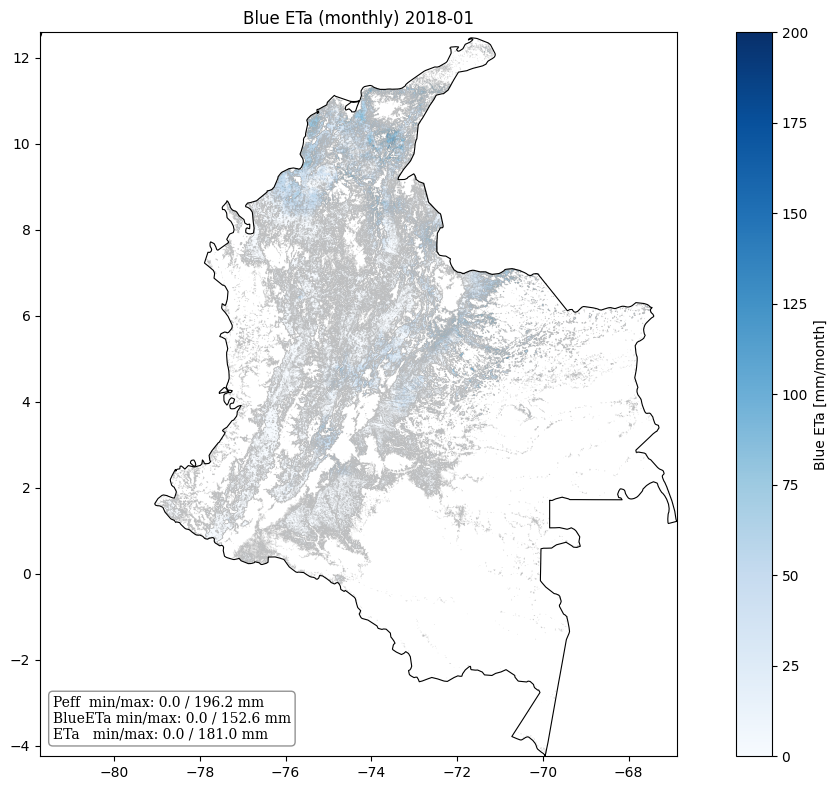

/tmp/ipython-input-4188487195.py:203: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df1], ignore_index=True)



Procesando mes: 2018-02
Peff min/max: 0.00 / 161.39
BlueETa min/max: 0.00 / 217.40
ETa min/max: 0.00 / 217.40
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-02.png


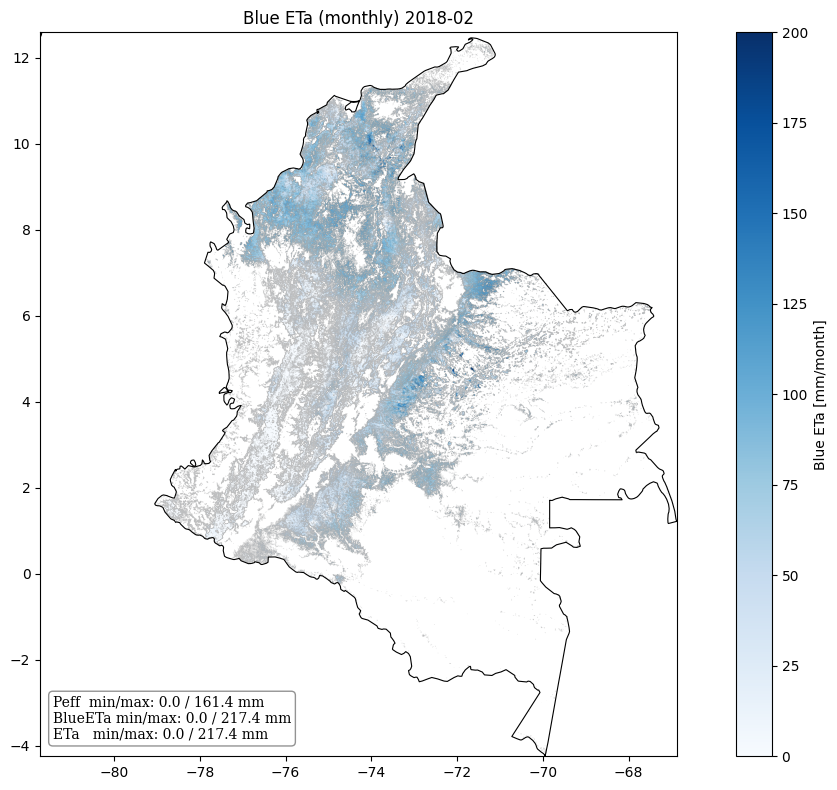


Procesando mes: 2018-03
Peff min/max: 0.00 / 192.97
BlueETa min/max: 0.00 / 172.90
ETa min/max: 0.00 / 208.00
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-03.png


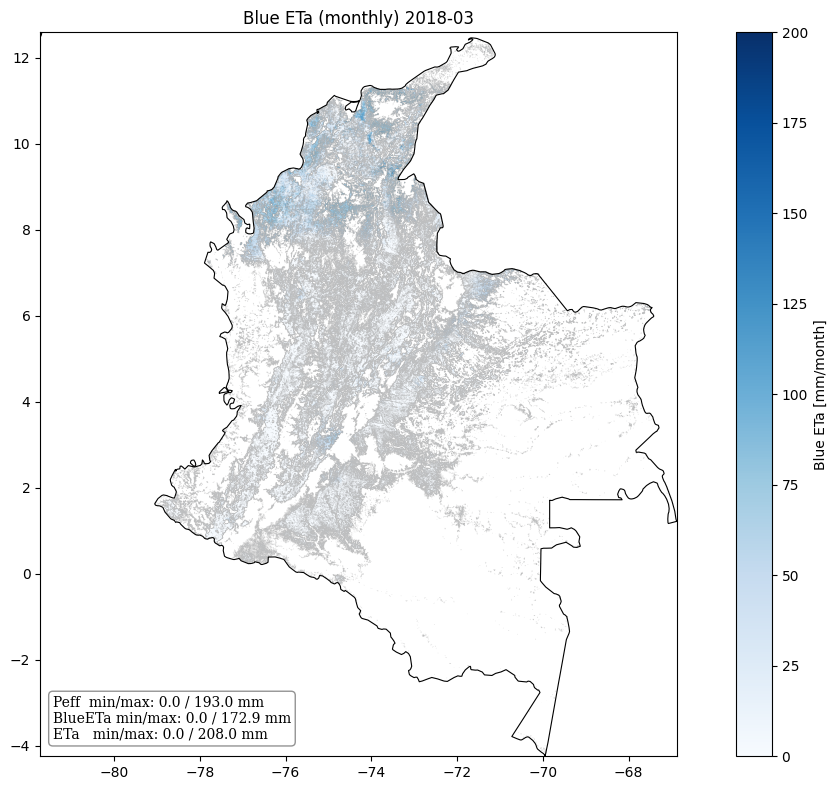


Procesando mes: 2018-04
Peff min/max: 0.00 / 195.54
BlueETa min/max: 0.00 / 122.11
ETa min/max: 0.00 / 148.00
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-04.png


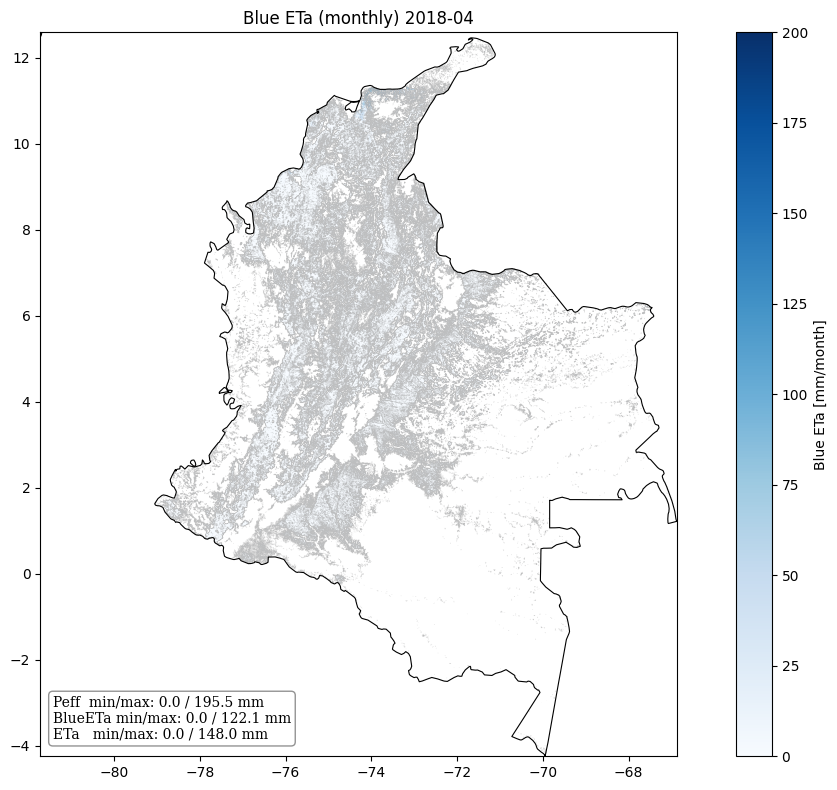


Procesando mes: 2018-05
Peff min/max: 0.00 / 239.80
BlueETa min/max: 0.00 / 115.53
ETa min/max: 0.00 / 157.30
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-05.png


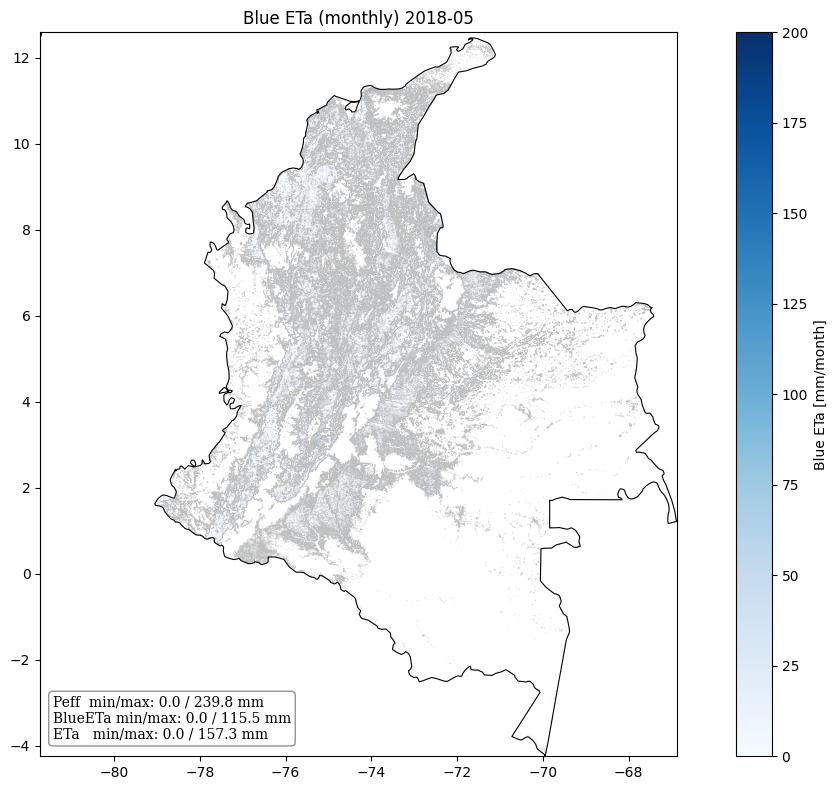


Procesando mes: 2018-06
Peff min/max: 0.00 / 243.89
BlueETa min/max: 0.00 / 129.58
ETa min/max: 0.00 / 172.00
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-06.png


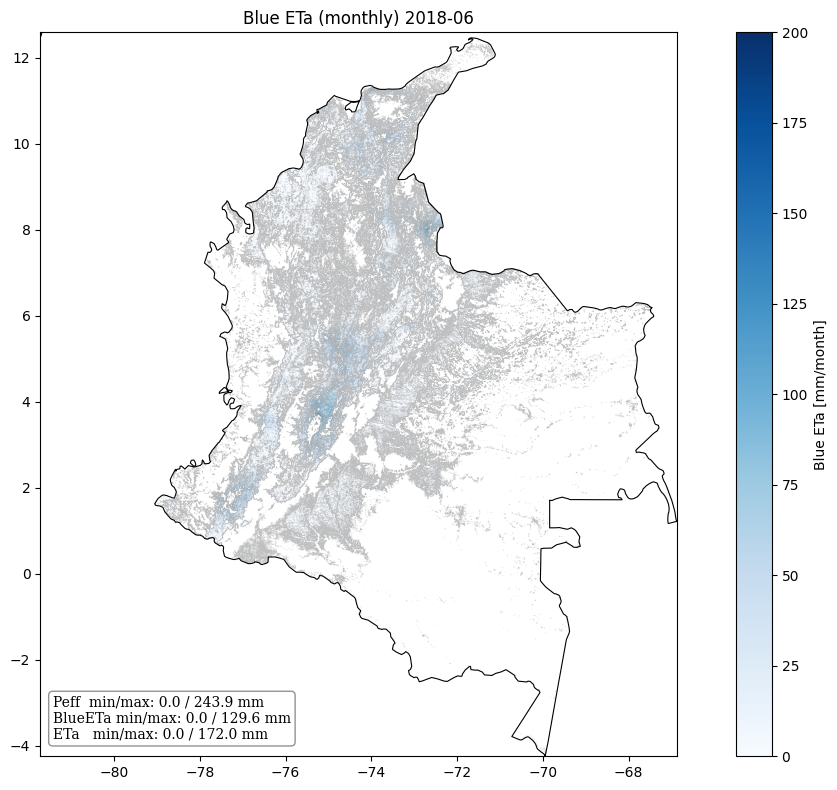


Procesando mes: 2018-07
Peff min/max: 0.00 / 226.03
BlueETa min/max: 0.00 / 156.80
ETa min/max: 0.00 / 184.10
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-07.png


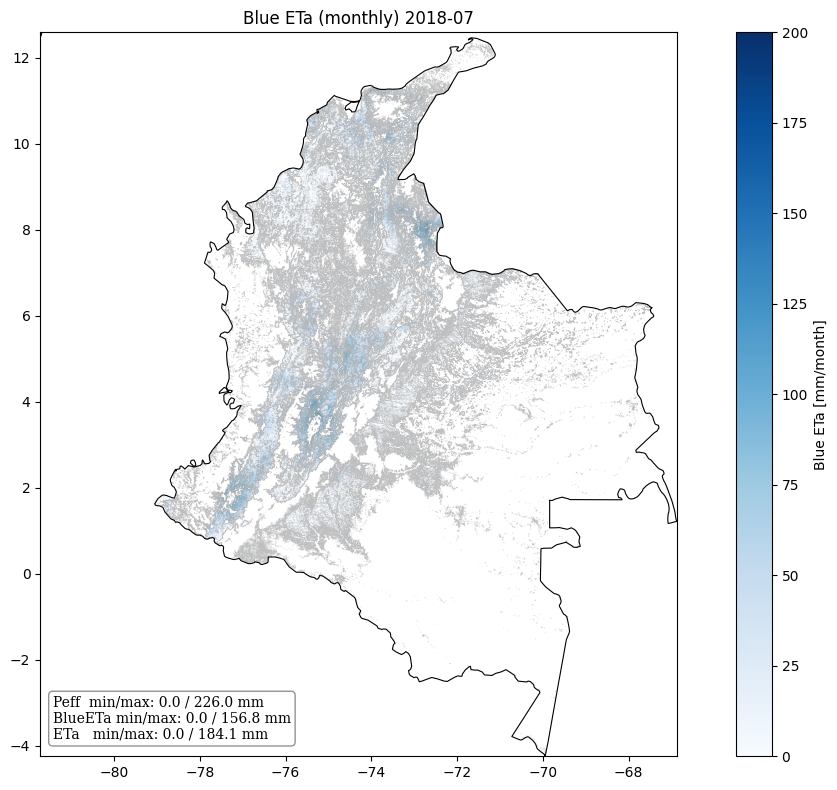


Procesando mes: 2018-08
Peff min/max: 0.10 / 206.18
BlueETa min/max: 0.00 / 168.24
ETa min/max: 0.00 / 192.70
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-08.png


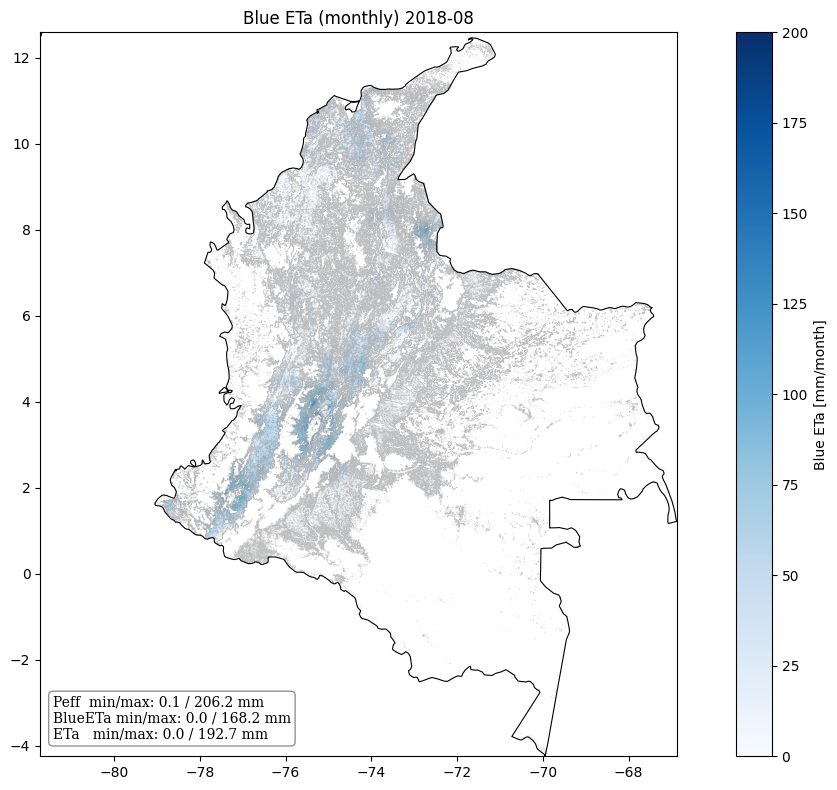


Procesando mes: 2018-09
Peff min/max: 0.20 / 200.75
BlueETa min/max: 0.00 / 121.32
ETa min/max: 0.00 / 182.00
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-09.png


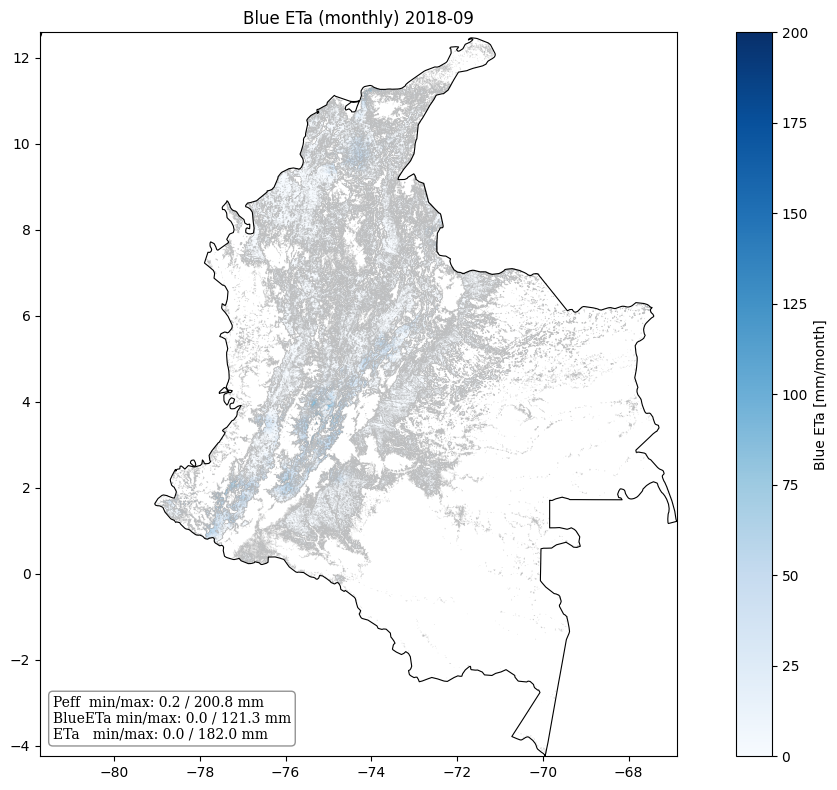


Procesando mes: 2018-10
Peff min/max: 3.78 / 240.08
BlueETa min/max: 0.00 / 118.22
ETa min/max: 0.00 / 153.90
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-10.png


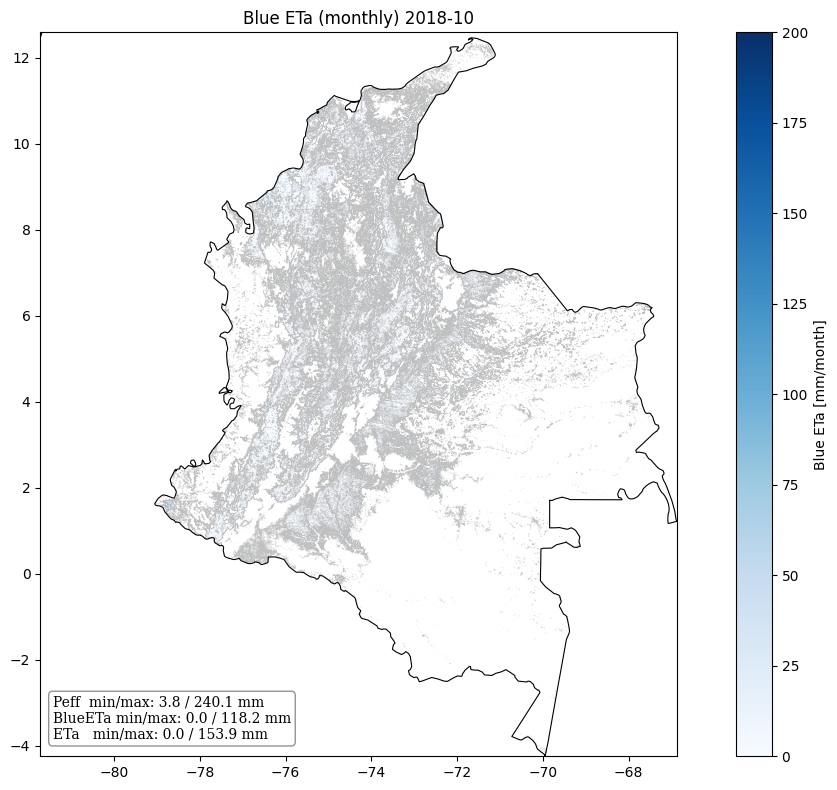


Procesando mes: 2018-11
Peff min/max: 0.20 / 220.03
BlueETa min/max: 0.00 / 112.79
ETa min/max: 0.00 / 156.00
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-11.png


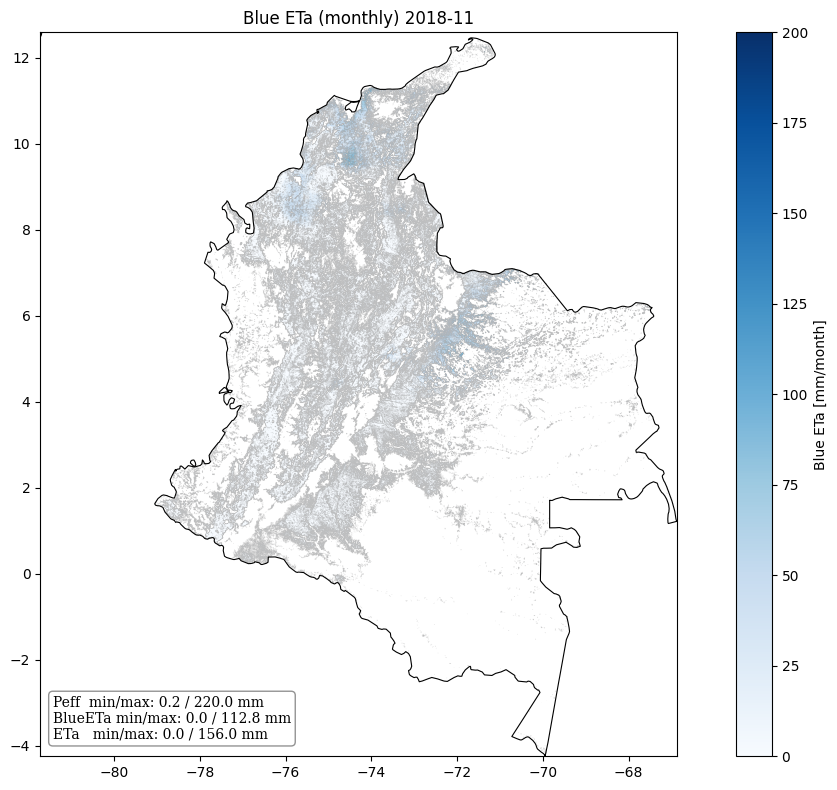


Procesando mes: 2018-12
Peff min/max: 0.00 / 208.26
BlueETa min/max: 0.00 / 183.03
ETa min/max: 0.00 / 187.60
[PNG] guardado: /content/output/GreenBlueET_season/figs_monthly/BlueETa_2018-12.png


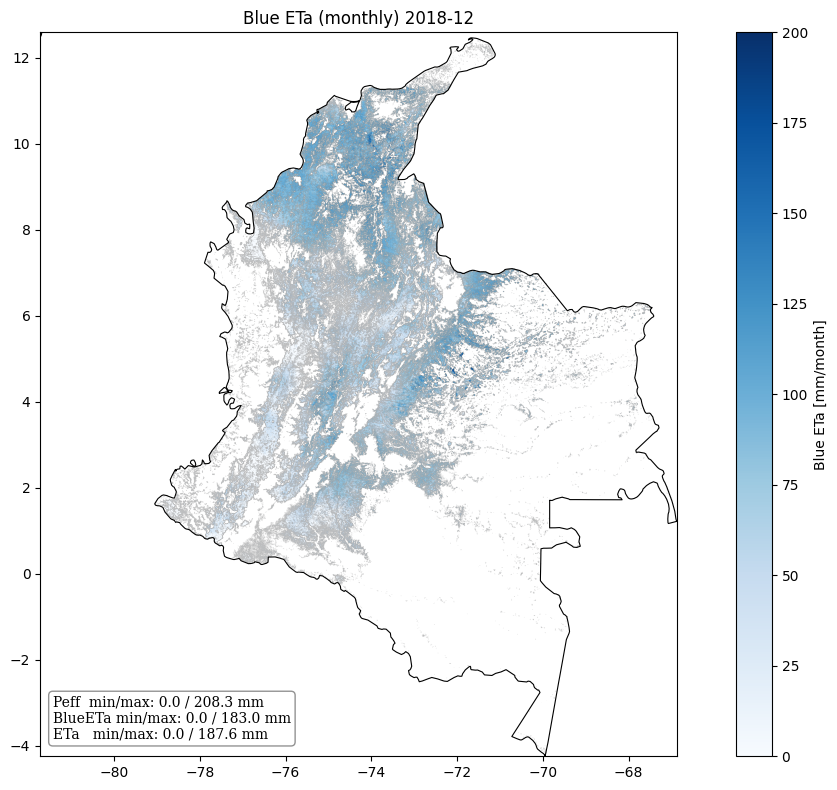


✓ Procesamiento mensual Green/Blue ETa completado.


,YearMonth,GreenETa_mean,GreenETa_SD,BlueETa_mean,BlueETa_SD,ETa_mean,ETa_SD
0,2018-01,70.618986,24.915014,13.474011,20.971846,84.092975,20.972336
1,2018-02,32.602295,27.465612,46.678658,35.395735,79.280966,25.225039
2,2018-03,62.508033,29.762556,12.326537,23.020063,74.834585,27.005937
3,2018-04,67.274237,21.634856,0.442939,4.183450,67.717174,21.493845
4,2018-05,76.510932,20.447219,0.241246,2.475841,76.752147,20.548766
5,2018-06,72.417809,22.127982,7.503655,15.933481,79.921435,23.452457
6,2018-07,77.128671,26.411631,11.880966,20.574389,89.009621,24.900803
7,2018-08,83.223622,30.406144,14.840029,24.620858,98.063623,23.260024
8,2018-09,85.463371,21.574754,4.796391,12.287315,90.259731,18.983430
9,2018-10,88.504668,17.863693,0.259019,2.544640,88.763667,17.957597


In [ ]:
import os, re, datetime
import numpy as np
import pandas as pd
import rioxarray as rio
import matplotlib.pyplot as plt
import gc

"""
Procesa rasters MENSUALES de Peff (input_fhsPeff) y ETa (input_fhsETa)
y calcula:
  GreenETa = min(Peff, ETa)
  BlueETa  = max(0, ETa - Peff)

Guarda GeoTIFF mensuales y PNGs (como tu estilo PCP/Peff).
Requiere: input_fhsPeff, input_fhsETa, output_folderGreenBlueET.
Opcional: col_gdf.
"""

# ---------- nodata ----------
nodata_value = -9999.0  # ajusta si tus rasters usan otro

# ---------- parser robusto (igual a tu PCP/Peff) ----------
def month_tag(fname):
    """
    Devuelve (tag 'YYYY-MM', date(YYYY,MM,1)) si puede; si no, (nombre_limpio, date.max).
    """
    base = os.path.basename(fname)

    # a) YYYY-MM(-DD)? / YYYY_MM / YYYY.MM / YYYYMM
    m = re.search(r'(?P<y>\d{4})[-_.]?(?P<m>0[1-9]|1[0-2])(?:[-_.]?\d{2})?', base)
    if m:
        y = int(m.group('y')); mm = int(m.group('m'))
        try:
            d = datetime.date(y, mm, 1)
            return f"{y:04d}-{mm:02d}", d
        except ValueError:
            pass

    # b) MM-YYYY / MM_YYYY
    m = re.search(r'(?P<m>0[1-9]|1[0-2])[-_.](?P<y>\d{4})', base)
    if m:
        y = int(m.group('y')); mm = int(m.group('m'))
        try:
            d = datetime.date(y, mm, 1)
            return f"{y:04d}-{mm:02d}", d
        except ValueError:
            pass

    tag = re.sub(r'\s+', '_', os.path.splitext(base)[0])
    return tag, datetime.date.max

# === Opción de filtro por año ===
year_to_run = 2018 # None para todos; o 2018,2019...

def select_year(files, y):
    if y is None:
        return [fh for fh in files if month_tag(fh)[1] != datetime.date.max]
    return [fh for fh in files if month_tag(fh)[1] != datetime.date.max and month_tag(fh)[1].year == y]

peff_sel = select_year(input_fhsPeff, year_to_run)
eta_sel  = select_year(input_fhsETa,  year_to_run)

# ---------- emparejar por tag YYYY-MM (robusto) ----------
peff_map = {month_tag(f)[0]: f for f in peff_sel}
eta_map  = {month_tag(f)[0]: f for f in eta_sel}

common_tags = sorted(set(peff_map.keys()) & set(eta_map.keys()),
                     key=lambda t: datetime.date(int(t[:4]), int(t[5:7]), 1))

print("Peff months:", len(peff_map), "ETa months:", len(eta_map), "Common:", len(common_tags))
if not common_tags:
    raise ValueError("No hay meses en común entre Peff y ETa. Revisa nombres/rutas.")

print("Ejemplo 1er par:", os.path.basename(peff_map[common_tags[0]]), "||", os.path.basename(eta_map[common_tags[0]]))

# ---------- carpetas de salida ----------
os.makedirs(output_folderGreenBlueET, exist_ok=True)
figs_dir = os.path.join(output_folderGreenBlueET, "figs_monthly")
os.makedirs(figs_dir, exist_ok=True)

# ---------- dataframe resumen ----------
df = pd.DataFrame(columns=[
    "YearMonth",
    "GreenETa_mean", "GreenETa_SD",
    "BlueETa_mean",  "BlueETa_SD",
    "ETa_mean",      "ETa_SD"
])

# ---------- loop mensual ----------
for tag in common_tags:
    fh_peff = peff_map[tag]
    fh_eta  = eta_map[tag]
    print(f"\nProcesando mes: {tag}")
    # --- leer y squeeze a 2D ---
    Peff = rio.open_rasterio(fh_peff).squeeze().astype("float64")
    ETa  = rio.open_rasterio(fh_eta ).squeeze().astype("float64")

    # --- nodata a NaN ---
    # Peff
    ndv_peff = Peff.rio.nodata if Peff.rio.nodata is not None else nodata_value
    Peff = Peff.rio.write_nodata(ndv_peff, inplace=False)
    Peff = Peff.where(Peff != ndv_peff)

    # ETa
    ndv_eta = ETa.rio.nodata if ETa.rio.nodata is not None else nodata_value
    ETa = ETa.rio.write_nodata(ndv_eta, inplace=False)
    ETa = ETa.where(ETa != ndv_eta)

    # (Opcional) evita negativos si no tienen sentido en tus datos
    Peff = Peff.where(Peff >= 0)
    ETa  = ETa.where(ETa  >= 0)

    # --- calcular Green / Blue (en arrays) ---
    Peff_data = Peff.values
    ETa_data  = ETa.values

    GreenETa = np.minimum(Peff_data, ETa_data)
    BlueETa  = np.maximum(0, ETa_data - Peff_data)

    # --- construir DataArrays preservando geo/coords ---
    GreenETa_da = Peff.copy(data=GreenETa)
    BlueETa_da  = Peff.copy(data=BlueETa)

    # --- guardar rasters ---
    out_green = os.path.join(output_folderGreenBlueET, f"GreenETa_{tag}.tif")
    out_blue  = os.path.join(output_folderGreenBlueET, f"BlueETa_{tag}.tif")

    GreenETa_da.rio.to_raster(out_green, nodata=ndv_peff, crs=Peff.rio.crs)
    BlueETa_da.rio.to_raster(out_blue,  nodata=ndv_peff, crs=Peff.rio.crs)

    # --- stats ---
    print(f"Peff min/max: {np.nanmin(Peff_data):.2f} / {np.nanmax(Peff_data):.2f}")
    print(f"BlueETa min/max: {np.nanmin(BlueETa):.2f} / {np.nanmax(BlueETa):.2f}")
    print(f"ETa min/max: {np.nanmin(ETa_data):.2f} / {np.nanmax(ETa_data):.2f}")

    # --- plot BlueETa estilo similar a tu PCP/Peff ---
    xmin, ymin, xmax, ymax = BlueETa_da.rio.bounds()
    spatial_extent = (xmin, xmax, ymin, ymax)

    fig, ax = plt.subplots(figsize=(12, 8))
    plot_max = 200
    blue_plot = np.clip(BlueETa_da.squeeze().values, 0, plot_max)

    try:
        im = ax.imshow(
            blue_plot,
            cmap='Blues', vmin=0, vmax=plot_max,
            extent=spatial_extent,
            origin='upper' if BlueETa_da.y.values[0] > BlueETa_da.y.values[-1] else 'lower'
        )
    except Exception as e:
        print(f"[{tag}] AVISO imshow con extent falló: {e} -> pruebo sin extent")
        im = ax.imshow(
            blue_plot,
            cmap='Blues', vmin=0, vmax=plot_max,
            origin='upper' if BlueETa_da.y.values[0] > BlueETa_da.y.values[-1] else 'lower'
        )

    # contorno opcional
    if 'col_gdf' in globals() and col_gdf is not None:
        try:
            if col_gdf.crs != BlueETa_da.rio.crs:
                col_gdf.to_crs(BlueETa_da.rio.crs).boundary.plot(ax=ax, linewidth=0.8, color='k')
            else:
                col_gdf.boundary.plot(ax=ax, linewidth=0.8, color='k')
        except Exception as e:
            print(f"[{tag}] AVISO contorno:", e)

    fig.colorbar(im, ax=ax, shrink=1, label='Blue ETa [mm/month]')
    ax.set_title(f'Blue ETa (monthly) {tag}', fontsize=12)

    # texto de stats
    stats_txt = (
        f"Peff  min/max: {np.nanmin(Peff_data):.1f} / {np.nanmax(Peff_data):.1f} mm\n"
        f"BlueETa min/max: {np.nanmin(BlueETa):.1f} / {np.nanmax(BlueETa):.1f} mm\n"
        f"ETa   min/max: {np.nanmin(ETa_data):.1f} / {np.nanmax(ETa_data):.1f} mm"
    )
    ax.text(
        0.02, 0.02, stats_txt,
        transform=ax.transAxes, va='bottom', ha='left',
        fontsize=10, family='DejaVu Serif',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.5')
    )

    fig.tight_layout()
    fig_path = os.path.join(figs_dir, f"BlueETa_{tag}.png")
    fig.savefig(fig_path, dpi=300, bbox_inches='tight', format='png')
    print(f"[PNG] guardado: {fig_path}")

    plt.show()
    plt.close(fig)

    # --- guardar stats en DF ---
    df1 = pd.DataFrame([{
        "YearMonth": tag,
        "GreenETa_mean": np.nanmean(GreenETa),
        "GreenETa_SD":   np.nanstd(GreenETa),
        "BlueETa_mean":  np.nanmean(BlueETa),
        "BlueETa_SD":    np.nanstd(BlueETa),
        "ETa_mean":      np.nanmean(ETa_data),
        "ETa_SD":        np.nanstd(ETa_data),
    }])
    df = pd.concat([df, df1], ignore_index=True)

    # liberar RAM
    del Peff, ETa, GreenETa_da, BlueETa_da, Peff_data, ETa_data, GreenETa, BlueETa
    gc.collect()

print("\n✓ Procesamiento mensual Green/Blue ETa completado.")
df


## **12. Zip and download data**

In [ ]:
# 1) Compress the specified folders into a single zip file
!zip -r /content/GreenBlueET_season.zip /content/output/GreenBlueET_season


# 2) Download the zipped file from Colab to your local machine
from google.colab import files
files.download(r'/content/GreenBlueET_season.zip')